Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**


**Fashion Classification Assessment**

---

### **Import Libraries**

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools

from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix


print(f'Tensorflow: {tf.__version__}\n',
      f'Pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}\n')


I0000 00:00:1781790455.187221   26096 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Tensorflow: 2.21.0
 Pandas: 3.0.2
 numpy: 2.4.2
 sklearn: 1.8.0



### **Prep Dataset**

In [2]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [3]:
train_data.shape, train_labels.shape

((60000, 28, 28), (60000,))

In [4]:
train_data[1]

array([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
         54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236,
        255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196,
        200, 215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199,
        201, 196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,
          0,   0],
       [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250,
        245, 249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,
         73,  48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,
          0,   0],
       [  

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

len(class_names)

10

In [6]:
train_data_normalized = train_data / 255.0
test_data_normalized = test_data / 255.0

train_data_normalized.min(), train_data_normalized.max()

(np.float64(0.0), np.float64(1.0))

### **Find the Ideal Learning Rate**

#### **Ideal Learning Rate for Raw Data**

In [7]:
tf.random.set_seed(42)

model_lr = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_lr.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

history_lr = model_lr.fit(train_data, train_labels, 
                    epochs=100,
                    batch_size=128,
                    callbacks=[lr_callback])  



/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1781790463.099199   26096 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/100


I0000 00:00:1781790465.535956   26301 service.cc:153] XLA service 0x7f13c80324d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781790465.536008   26301 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1781790465.561042   26301 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781790465.724263   26301 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1781790465.735855   26301 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1253__.13
I0000 00:00:1781790465.760903   26301 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

 34/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1567 - loss: 93.1265 

I0000 00:00:1781790471.541902   26301 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


463/469 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5223 - loss: 26.3654

I0000 00:00:1781790473.655470   26301 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1253__.13
I0000 00:00:1781790474.490181   26301 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781790475.331461   26301 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781790475.877320   26561 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1781790475.918084   26301 dot_search_space.cc:240] All configs were filtered out because none 

469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.6409 - loss: 12.1725 - learning_rate: 1.0000e-04
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7490 - loss: 3.6464 - learning_rate: 1.1220e-04
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7725 - loss: 2.3120 - learning_rate: 1.2589e-04
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7854 - loss: 1.6581 - learning_rate: 1.4125e-04
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7961 - loss: 1.2683 - learning_rate: 1.5849e-04
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8114 - loss: 1.0102 - learning_rate: 1.7783e-04
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8220 - loss: 0.8299 - learning_rate: 1.9953e-04
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8318 - loss: 0.7100 - learning_rate: 2.2387e-04
Epoch 9/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8393 - loss: 0.6153 - 

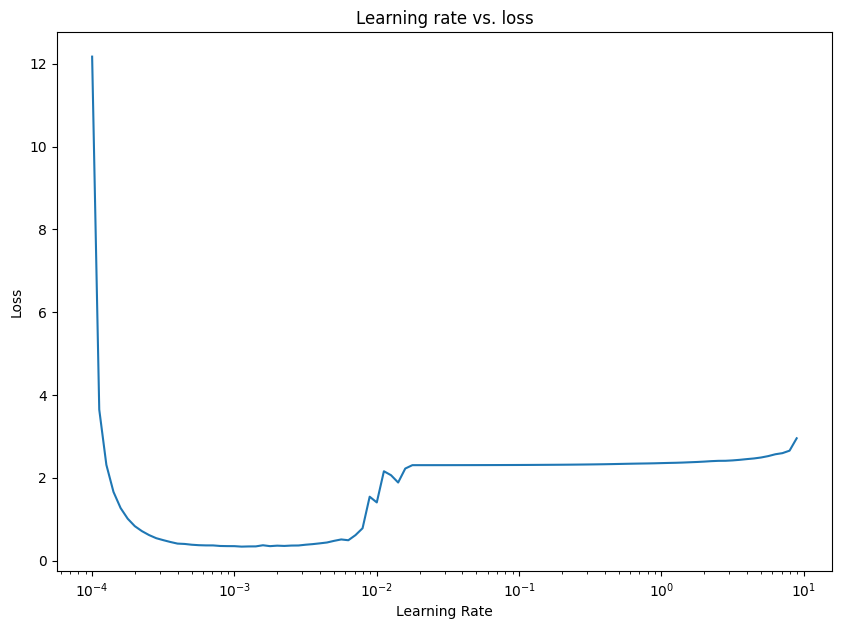

In [8]:
lrs = 1e-4 * (10 ** (np.arange(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_lr.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

as per the graph above, somewhere around ```learning_rate = 0.0014``` is the safest option.

#### **Ideal Learning Rate for Normalized Data**

In [9]:
tf.random.set_seed(42)

model_normalized_lr = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_normalized_lr.compile(loss='sparse_categorical_crossentropy',
                         optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                         metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

history_normalized_lr = model_normalized_lr.fit(train_data_normalized, train_labels,
                                                epochs=100,
                                                batch_size=128,
                                                callbacks=[lr_callback]
                                                )


Epoch 1/100


I0000 00:00:1781790717.361895   26302 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_191849__.13


460/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5817 - loss: 1.3565

I0000 00:00:1781790722.286470   26299 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_191849__.13


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7109 - loss: 0.9350 - learning_rate: 1.0000e-04
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8208 - loss: 0.5340 - learning_rate: 1.1220e-04
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8400 - loss: 0.4667 - learning_rate: 1.2589e-04
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8516 - loss: 0.4301 - learning_rate: 1.4125e-04
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8589 - loss: 0.4052 - learning_rate: 1.5849e-04
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8641 - loss: 0.3861 - learning_rate: 1.7783e-04
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8688 - loss: 0.3707 - learning_rate: 1.9953e-04
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8730 - loss: 0.3571 - learning_rate: 2.2387e-04
Epoch 9/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8766 - loss: 0.3452 - le

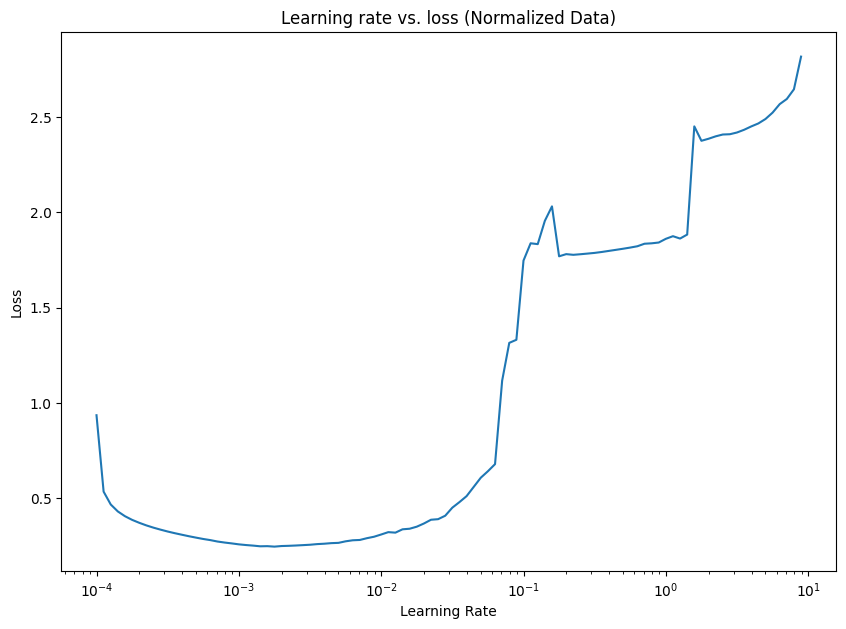

In [10]:
lrs = 1e-4 * (10 ** (np.arange(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_normalized_lr.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. loss (Normalized Data)");


as per the graph above, somewhere around ```learning_rate = 0.0013``` is the safest option.

### **Create Model with Optimal Learning Rate**

#### **Model Trained on Raw Data**

In [11]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0011),
              metrics=['accuracy'])

history = model.fit(train_data, train_labels,
                    epochs=20,
                    batch_size=128,
                    validation_data=(test_data, test_labels))


Epoch 1/20


I0000 00:00:1781790962.026532   26300 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_382444__.13


464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6762 - loss: 12.1183

I0000 00:00:1781790966.440166   26300 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_382444__.13


469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7447 - loss: 4.2438 - val_accuracy: 0.7793 - val_loss: 1.1729
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7949 - loss: 0.8794 - val_accuracy: 0.7980 - val_loss: 0.7646
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8198 - loss: 0.6022 - val_accuracy: 0.8182 - val_loss: 0.6475
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8329 - loss: 0.5052 - val_accuracy: 0.8292 - val_loss: 0.5731
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8433 - loss: 0.4589 - val_accuracy: 0.8360 - val_loss: 0.5474
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8492 - loss: 0.4352 - val_accuracy: 0.8273 - val_loss: 0.5495
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8548 - loss: 0.4134 - val_accuracy: 0.8401 - val_loss: 0.5019
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8574 - loss: 0.4068 - val_accuracy: 0.8318 - va

#### **Model Trained on Normalized Data**

In [12]:
tf.random.set_seed(42)

model_normalized = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_normalized.compile(loss='sparse_categorical_crossentropy',
                         optimizer=tf.keras.optimizers.Adam(learning_rate=0.0013),
                         metrics=['accuracy'])

history_normalized = model_normalized.fit(
    train_data_normalized,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_data=(test_data_normalized, test_labels)
)


Epoch 1/20


I0000 00:00:1781791022.413088   26302 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_428266__.13


462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7487 - loss: 0.7160

I0000 00:00:1781791026.167963   26299 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_428266__.13


469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8130 - loss: 0.5268 - val_accuracy: 0.8397 - val_loss: 0.4444
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8643 - loss: 0.3824 - val_accuracy: 0.8568 - val_loss: 0.4016
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8763 - loss: 0.3442 - val_accuracy: 0.8611 - val_loss: 0.3855
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8841 - loss: 0.3184 - val_accuracy: 0.8645 - val_loss: 0.3841
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8897 - loss: 0.3001 - val_accuracy: 0.8636 - val_loss: 0.3888
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8960 - loss: 0.2842 - val_accuracy: 0.8613 - val_loss: 0.3908
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9000 - loss: 0.2701 - val_accuracy: 0.8650 - val_loss: 0.3845
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9042 - loss: 0.2583 - val_accuracy: 0.8660 - val

### **Display Results**

In [13]:
import random

# Create a function for plotting a random image along with its prediction
def plot_random_image(model, images, true_labels, classes):
  """Picks a random image, plots it and labels it with a predicted and truth label.

  Args:
    model: a trained model (trained on data similar to what's in images).
    images: a set of random images (in tensor form).
    true_labels: array of ground truth labels for images.
    classes: array of class names for images.

  Returns:
    A plot of a random image from `images` with a predicted class label from `model`
    as well as the truth class label from `true_labels`.
  """
  # Setup random integer
  i = random.randint(0, len(images))

  # Create predictions and targets
  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1, 28, 28)) # have to reshape to get into right size for model
  pred_label = classes[pred_probs.argmax()]
  true_label = classes[true_labels[i]]

  # Plot the target image
  plt.imshow(target_image, cmap=plt.cm.binary)

  # Change the color of the titles depending on if the prediction is right or wrong
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  # Add xlabel information (prediction/true label)
  plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                   100*tf.reduce_max(pred_probs),
                                                   true_label),
             color=color) # set the color to green or red

In [14]:
def plot_image(model, images, true_labels, classes, index):
  """Plots a single image and labels it with a predicted and truth label.

  Args:
    model: a trained model (trained on data similar to what's in images).
    images: image array to select from.
    true_labels: array of ground truth labels for images.
    classes: array of class names for images.
    index: index of the image to plot.

  Returns:
    A plot of the image at index `index`.
  """
  target_image = images[index]
  true_label = classes[true_labels[index]]

  pred_probs = model.predict(tf.expand_dims(target_image, axis=0), verbose=0)
  pred_label = classes[pred_probs.argmax()]

  plt.imshow(target_image, cmap=plt.cm.binary)

  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  plt.xlabel(
      f"Pred: {pred_label} {100 * tf.reduce_max(pred_probs):.2f}% | True: {true_label}",
      color=color
  )


In [15]:
def make_confusion_matrix(
    y_true,
    y_pred,
    classes=None,
    figsize=(10, 10),
    text_size=15,
    title="Confusion Matrix"
):
  """Makes a labelled confusion matrix comparing predictions and truth labels."""
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
  n_classes = cm.shape[0]

  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues)
  fig.colorbar(cax)

  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  ax.set(title=title,
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes),
         yticks=np.arange(n_classes),
         xticklabels=labels,
         yticklabels=labels)

  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  threshold = (cm.max() + cm.min()) / 2.

  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j] * 100:.1f}%)",
             horizontalalignment="center",
             color="white" if cm[i, j] > threshold else "black",
             size=text_size)


#### **Accuracy / Loss Graph**

Text(0.5, 1.0, 'Normalized Data Model Training')

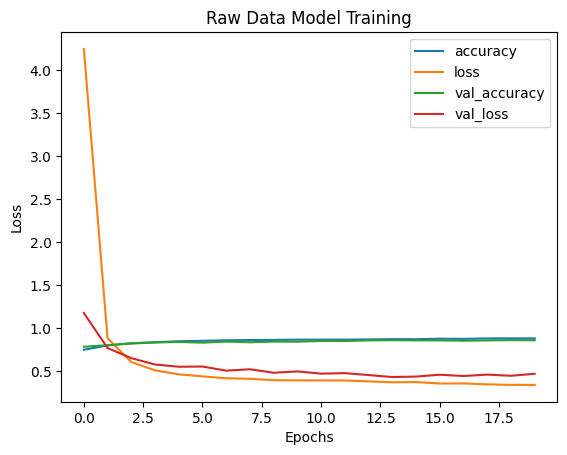

<Figure size 640x480 with 0 Axes>

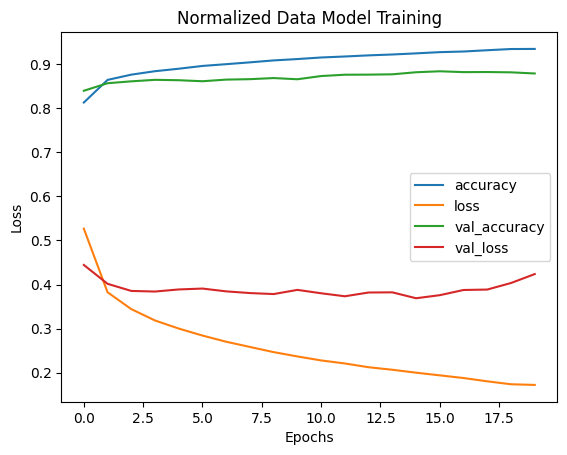

In [16]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')
mpl.pyplot.title('Raw Data Model Training')

plt.figure()
pd.DataFrame(history_normalized.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')
mpl.pyplot.title('Normalized Data Model Training')


#### **Normalized vs Raw Training Sets**

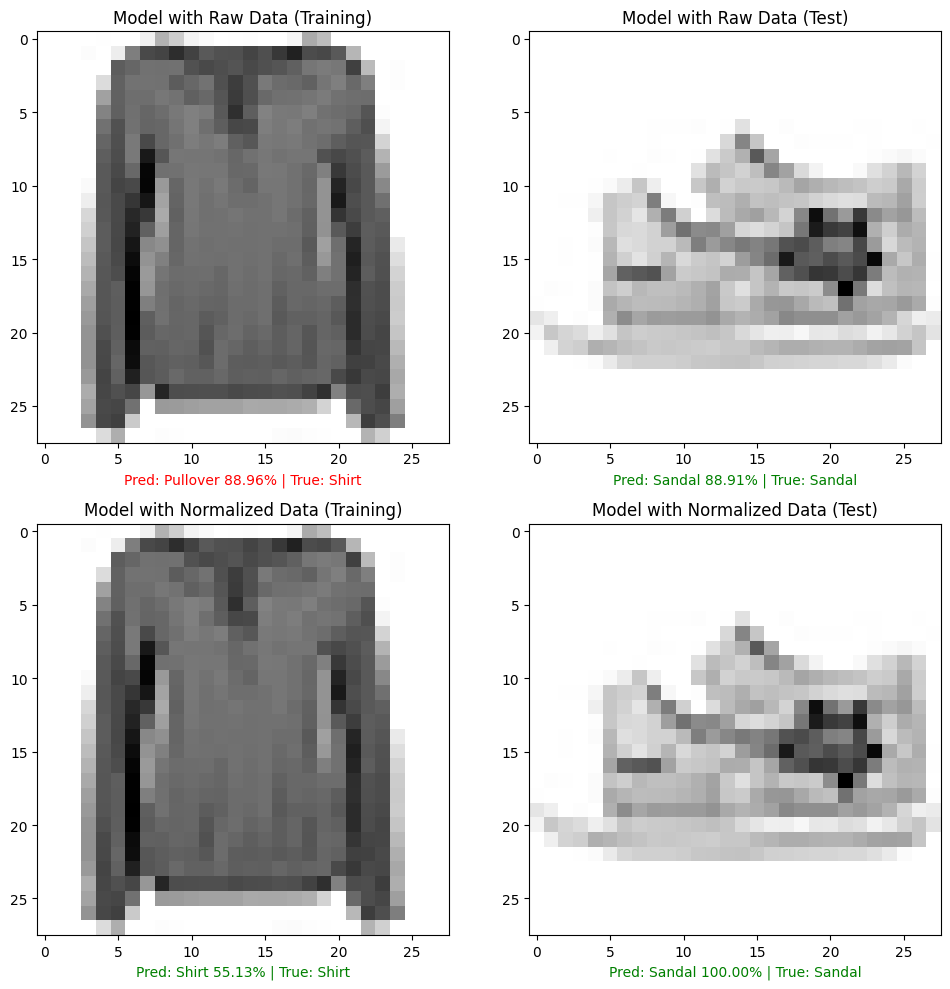

In [17]:
comparison_index = len(test_data) - 1

plt.figure(figsize=(10, 10))

plots = [
    ('Model with Raw Data (Training)', model, train_data, train_labels, comparison_index),
    ('Model with Raw Data (Test)', model, test_data, test_labels, comparison_index),
    ('Model with Normalized Data (Training)', model_normalized, train_data_normalized, train_labels, comparison_index),
    ('Model with Normalized Data (Test)', model_normalized, test_data_normalized, test_labels, comparison_index)
]

for i, (title, selected_model, img_data, labels, index) in enumerate(plots):
    plt.subplot(2, 2, i + 1)
    plt.title(title)

    plot_image(
        selected_model,
        img_data,
        labels,
        class_names,
        index
    )

plt.tight_layout()


#### **Confusion Matrices Comparison**

In [18]:
y_probs_raw = model.predict(test_data)
y_preds_raw = y_probs_raw.argmax(axis=1)
cm_raw = confusion_matrix(test_labels, y_preds_raw)
print("Raw Data Model Confusion Matrix:")
print(cm_raw)

y_probs_normalized = model_normalized.predict(test_data_normalized)
y_preds_normalized = y_probs_normalized.argmax(axis=1)
cm_normalized = confusion_matrix(test_labels, y_preds_normalized)
print("Normalized Data Model Confusion Matrix:")
print(cm_normalized)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Raw Data Model Confusion Matrix:
[[784   1  17  20   1   0 174   0   3   0]
 [  8 946   2  30   2   0  10   0   2   0]
 [ 11   0 873   9  54   0  51   0   2   0]
 [ 42   6  21 832  32   0  63   0   4   0]
 [  1   1 224  23 687   0  62   0   2   0]
 [  0   0   0   0   0 936   0  38   4  22]
 [110   1 167  24  70   0 620   0   8   0]
 [  0   0   0   0   0  11   0 966   5  18]
 [  3   0   8   5   0   1  17   2 964   0]
 [  0   0   0   1   0  11   1  42   0 945]]
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Normalized Data Model Confusion Matrix:
[[820   1  14  38   6   0 118   0   3   0]
 [  3 970   2  19   1   0   5   0   0   0]
 [ 22   0 838  17  73   0  50   0   0   0]
 [ 15   6   8 921  19   0  31   0   0   0]
 [  1   0 124  42 772   0  61   0   0   0]
 [  0   0   0   1   0 965   0  22   1  11]
 [100   0  99  35  64   0 697   0   5   0]
 [  0   0   0   0   0  19   0 975   0   6]
 [  6   2   9  10   6   5  11   3 948   0]
 [  0   0   0   1   0  12  

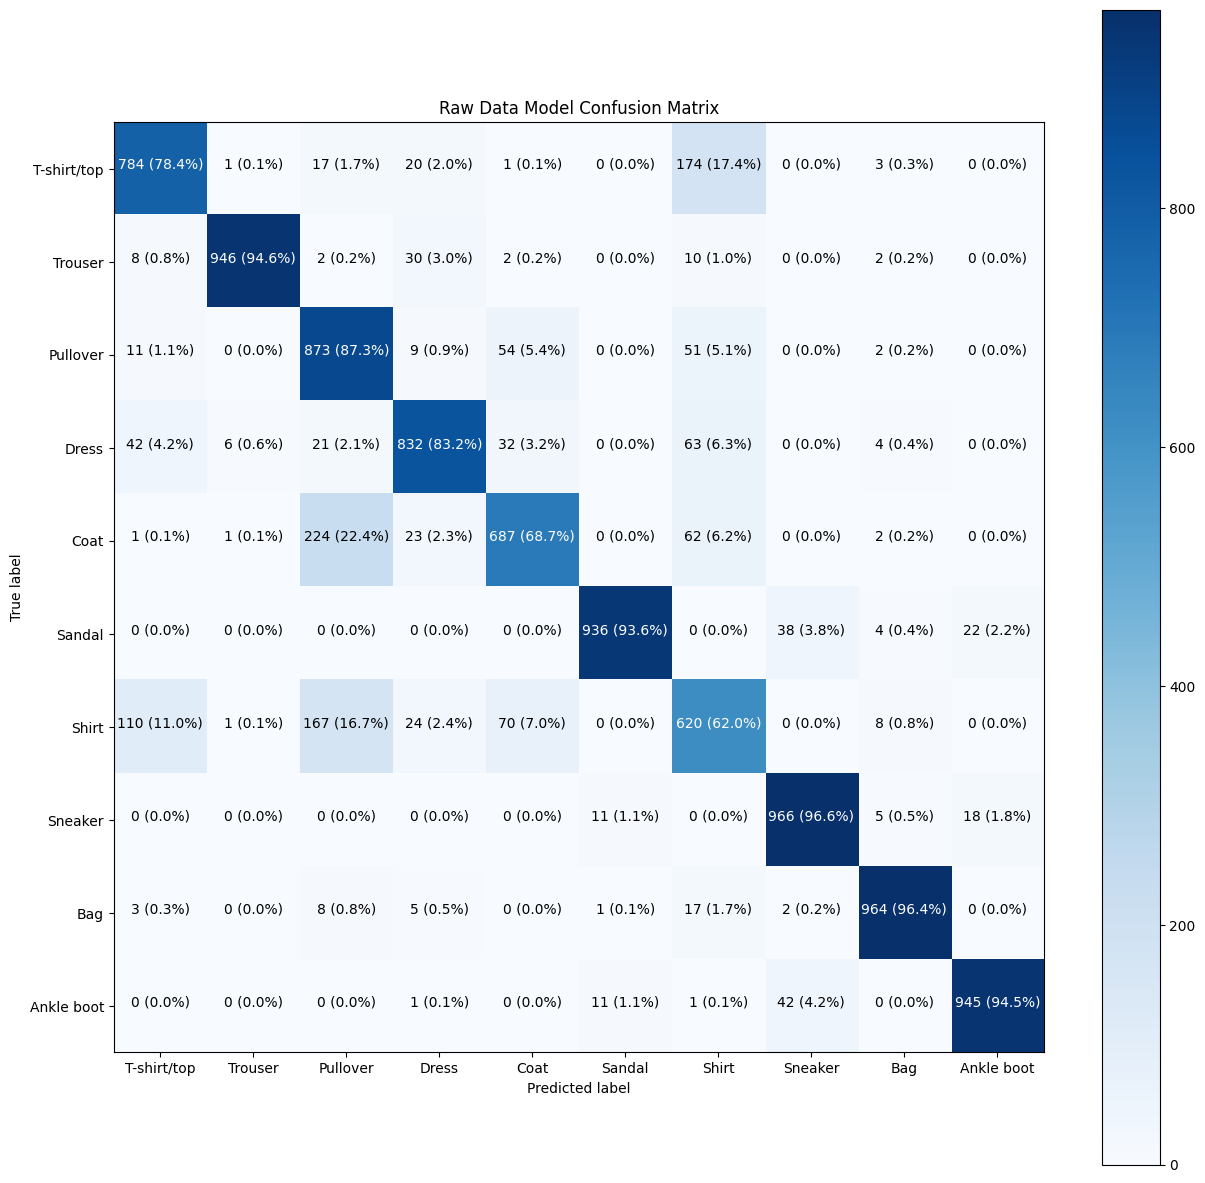

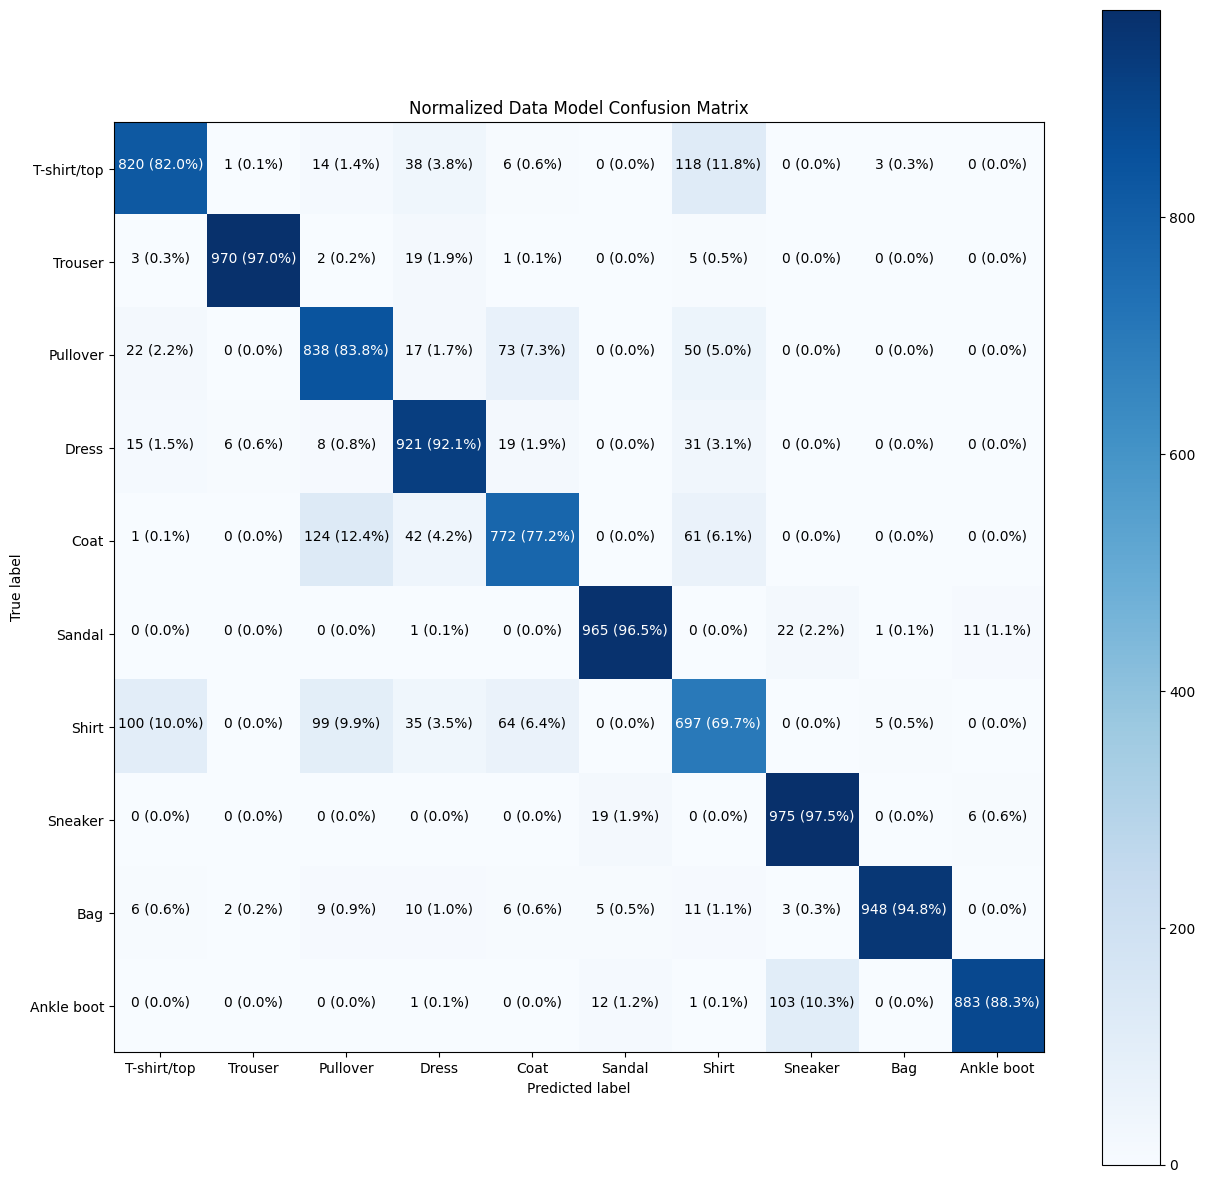

In [19]:
make_confusion_matrix(y_true=test_labels,
                      y_pred=y_preds_raw,
                      classes=class_names,
                      figsize=(15, 15),
                      text_size=10,
                      title="Raw Data Model Confusion Matrix")

make_confusion_matrix(y_true=test_labels,
                      y_pred=y_preds_normalized,
                      classes=class_names,
                      figsize=(15, 15),
                      text_size=10,
                      title="Normalized Data Model Confusion Matrix")
